In [1]:
import sys
import os
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# La dirección de este documento
cwd = os.getcwd()
current_dir = os.path.dirname(os.path.abspath(cwd))

# La dirección del proyecto (dos niveles por encima)
project_dir = os.path.normpath(os.path.join(current_dir, ".."))

print(project_dir)
print(current_dir)

c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy
c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy\Code


In [4]:
import sys
import os
import numpy as np  
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# La dirección de este documento
cwd = os.getcwd()
current_dir = os.path.dirname(os.path.abspath(cwd))

# La dirección del proyecto (dos niveles por encima)
project_dir = os.path.normpath(os.path.join(current_dir, ".."))

# Agregar el directorio del proyecto al sys.path para importar módulos personalizados
sys.path.append(project_dir)

print(f"Current working directory: {cwd}")
print(f"Current directory: {current_dir}")
print(f"Project directory: {project_dir}")  

from Code.config import ShellParams
from Code.runner import ShellRunner

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

C_NUM  = '#2563EB'   # azul   — RK4
C_ANA  = '#DC2626'   # rojo   — analítico
C_HOR  = '#16A34A'   # verde  — horizonte
C_VEFF = '#7C3AED'   # morado — potencial efectivo

Current working directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy\Code\visual
Current directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy\Code
Project directory: c:\Users\santi\Documents\Tesis_Collapse_of_matter_into_black_shell\26_04_26\project_copy


In [5]:
M = 1.0
b = 3.0    # a = M/b = 0.333 → positive_binding, R_max = 2.25

#### correr la simulación para  rk4, comparar con la solución analítica, y mostrar el dashboard

def run_simulation(M, b):
    params = ShellParams(M=M, b=b, integrator='rk4',
                         rtol=1e-10, atol=1e-12).validate()
    runner = ShellRunner(params)
    result = runner.run()
    bench  = runner.get_analytic_benchmark()
    report = runner.validate(result, bench)
    return params, result, bench, report

def dashboard(M, b, save=True):
    """Panel de 4 gráficas para un par (M, b)."""

    params, result, bench, report = run_simulation(M, b)
    rs        = params.rs
    R_max     = params.R_max
    a         = params.a
    tau_cross = result.horizon_crossing_tau

    print(params.summary())
    print(report.summary())

    fig = plt.figure(figsize=(13, 10))
    fig.suptitle(
        r'Colapso gravitacional de thin shell de polvo — Israel (1967)' + '\n'
        rf'$M={M}$,  $b={b}$,  $a={a:.3f}$,  '
        rf'$R_{{\rm max}}={R_max:.3f}$,  $r_s={rs:.1f}$',
        fontsize=12, y=0.98
    )

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        left=0.08, right=0.96, top=0.90, bottom=0.07,
        wspace=0.32, hspace=0.40
    )
    ax_tau   = fig.add_subplot(gs[0, 0])
    ax_phase = fig.add_subplot(gs[0, 1])
    ax_veff  = fig.add_subplot(gs[1, 0])
    ax_err   = fig.add_subplot(gs[1, 1])

    # ── Panel 1: R(τ) ─────────────────────────────────────────────────────────
    ax_tau.plot(result.tau, result.R, color=C_NUM, lw=2.0,
                label='RK4 (numérico)')
    ax_tau.plot(bench.tau,  bench.R,  color=C_ANA, lw=1.4, ls='--',
                label='Analítico (Israel 1967)')
    ax_tau.axhline(rs,    color=C_HOR,  ls=':', lw=1.3, alpha=0.85,
                   label=rf'$r_s = {rs}$')
    ax_tau.axhline(R_max, color='gray', ls=':', lw=1.0, alpha=0.6,
                   label=rf'$R_{{\rm max}} = {R_max:.3f}$')

    if tau_cross:
        ax_tau.axvline(tau_cross, color=C_HOR, ls='--', lw=0.9, alpha=0.5)
        ax_tau.annotate(
            rf'$\tau_{{\rm cruce}} = {tau_cross:.3f}$',
            xy=(tau_cross, rs),
            xytext=(tau_cross + 0.08*result.tau[-1], rs + 0.12*(R_max - rs)),
            fontsize=8, color=C_HOR,
            arrowprops=dict(arrowstyle='->', color=C_HOR, lw=0.8)
        )

    ax_tau.set_xlabel(r'$\tau$ (tiempo propio)')
    ax_tau.set_ylabel(r'$R(\tau)$')
    ax_tau.set_title(r'Trayectoria $R(\tau)$')
    ax_tau.set_ylim(bottom=0)
    ax_tau.legend()

    # ── Panel 2: Espacio de fase ───────────────────────────────────────────────
    ax_phase.plot(result.R, result.Rdot, color=C_NUM, lw=2.0, label='RK4')
    ax_phase.plot(bench.R,  bench.Rdot,  color=C_ANA, lw=1.4, ls='--',
                  label='Analítico')
    ax_phase.scatter([R_max], [0], color=C_NUM, s=55, zorder=5)
    ax_phase.annotate(r'$(R_{\rm max},\,0)$',
                      xy=(R_max, 0), xytext=(R_max - 0.35, 0.06),
                      fontsize=8, color=C_NUM)
    ax_phase.axvline(rs,    color=C_HOR,  ls=':', lw=1.3, alpha=0.85,
                     label=r'$r_s$')
    ax_phase.axvline(R_max, color='gray', ls=':', lw=1.0, alpha=0.6,
                     label=r'$R_{\rm max}$')
    ax_phase.axhline(0, color='gray', lw=0.5, alpha=0.4)
    ax_phase.set_xlabel(r'$R$')
    ax_phase.set_ylabel(r'$\dot{R} = dR/d\tau$')
    ax_phase.set_title('Espacio de fase')
    ax_phase.legend()

    # ── Panel 3: Potencial efectivo ────────────────────────────────────────────
    # C = 1 + Ṙ² − (a + b/2R)² = 0
    # → Ṙ² = (a + b/2R)² − 1 = −V_eff
    # → V_eff(R) = 1 − (a + b/2R)²
    R_plot = np.linspace(0.28*rs, R_max*1.12, 700)
    V_eff  = 1.0 - (a + b / (2*R_plot))**2

    ax_veff.plot(R_plot, V_eff, color=C_VEFF, lw=2.2,
                 label=r'$V_{\rm eff}(R) = 1 - (a + b/2R)^2$')
    ax_veff.axhline(0, color=C_ANA, ls='--', lw=1.3, alpha=0.8,
                    label=r'$E = 0$')
    ax_veff.axvline(rs,    color=C_HOR,  ls=':', lw=1.3, alpha=0.85,
                    label=rf'$r_s = {rs}$')
    ax_veff.axvline(R_max, color='gray', ls=':', lw=1.0, alpha=0.6,
                    label=rf'$R_{{\rm max}}$')

    ax_veff.fill_between(R_plot, V_eff, 0,
                         where=(V_eff < 0), color=C_VEFF, alpha=0.10,
                         label='Región de colapso')
    ax_veff.scatter([R_max], [0], color='gray', s=50, zorder=5)
    ax_veff.annotate(r'$R_{\rm max}$',
                     xy=(R_max, 0), xytext=(R_max - 0.28, 0.05),
                     fontsize=8, color='gray')

    ax_veff.set_xlabel(r'$R$')
    ax_veff.set_ylabel(r'$V_{\rm eff}(R)$')
    ax_veff.set_title('Potencial efectivo')
    ax_veff.set_ylim(-1.5, 0.35)
    ax_veff.legend(fontsize=8)

    # ── Panel 4: Precisión numérica ────────────────────────────────────────────
    tau_lo  = max(result.tau[0], bench.tau[0])
    tau_hi  = min(result.tau[-1], bench.tau[-1])
    tau_c   = np.linspace(tau_lo, tau_hi, 3000)
    R_err   = np.abs(
        np.interp(tau_c, result.tau, result.R) -
        np.interp(tau_c, bench.tau,  bench.R)
    )

    ax_err2 = ax_err.twinx()
    ax_err.semilogy(tau_c, R_err + 1e-16,
                    color=C_NUM, lw=1.8,
                    label=r'$|R_{\rm num} - R_{\rm ana}|$')
    ax_err2.semilogy(result.tau, np.abs(result.C) + 1e-16,
                     color=C_ANA, lw=1.4, ls='--', alpha=0.85,
                     label=r'$|\mathcal{C}|$ numérico')
    ax_err2.semilogy(bench.tau, np.abs(bench.C) + 1e-16,
                     color='gray', lw=1.0, ls=':', alpha=0.7,
                     label=r'$|\mathcal{C}|$ analítico')

    if tau_cross:
        ax_err.axvline(tau_cross, color=C_HOR, ls='--', lw=0.9, alpha=0.5,
                       label=r'$\tau_{\rm cruce}$')

    ax_err.set_xlabel(r'$\tau$')
    ax_err.set_ylabel(r'$|R_{\rm num} - R_{\rm ana}|$', color=C_NUM)
    ax_err2.set_ylabel(r'$|\mathcal{C}|$', color=C_ANA)
    ax_err.set_title('Precisión numérica')
    ax_err.tick_params(axis='y', labelcolor=C_NUM)
    ax_err2.tick_params(axis='y', labelcolor=C_ANA)

    lines1, labels1 = ax_err.get_legend_handles_labels()
    lines2, labels2 = ax_err2.get_legend_handles_labels()
    ax_err.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    if save:
        fname = 'dashboard_shell_collapse.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Guardado: {fname}')
    plt.show()


In [6]:
def parametric_scan(M, b_values=None, save=True):
    """Compara trayectorias para distintos valores de b."""

    if b_values is None:
        b_values = [2.0, 3.0, 5.0, 10.0]

    rs     = 2.0 * M
    colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(b_values)))
    R_veff = np.linspace(0.3*rs, 12.0, 600)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    fig.suptitle(rf'Escaneo paramétrico en $b$ con $M={M}$ fijo', fontsize=12)

    for b_val, color in zip(b_values, colors):
        try:
            p     = ShellParams(M=M, b=b_val, integrator='rk4',
                                rtol=1e-10, atol=1e-12).validate()
            r     = ShellRunner(p).run()
            a_val = p.a
            label = rf'$b={b_val}$, $a={a_val:.2f}$'

            axes[0].plot(r.tau, r.R,    color=color, lw=1.8, label=label)
            axes[1].plot(r.R,   r.Rdot, color=color, lw=1.8, label=label)

            V = 1.0 - (a_val + b_val/(2*R_veff))**2
            axes[2].plot(R_veff, V, color=color, lw=1.8, label=label)

        except Exception as e:
            print(f'b={b_val}: {e}')

    axes[0].axhline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.7, label=r'$r_s$')
    axes[0].set_xlabel(r'$\tau$'); axes[0].set_ylabel(r'$R(\tau)$')
    axes[0].set_title(r'Trayectorias $R(\tau)$'); axes[0].set_ylim(bottom=0)

    axes[1].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.7, label=r'$r_s$')
    axes[1].axhline(0, color='gray', lw=0.5, alpha=0.4)
    axes[1].set_xlabel(r'$R$'); axes[1].set_ylabel(r'$\dot{R}$')
    axes[1].set_title('Espacio de fase')

    axes[2].axhline(0, color=C_ANA, ls='--', lw=1.0, alpha=0.7, label='$E=0$')
    axes[2].axvline(rs, color=C_HOR, ls=':', lw=1.0, alpha=0.7, label=r'$r_s$')
    axes[2].set_xlabel(r'$R$'); axes[2].set_ylabel(r'$V_{\rm eff}$')
    axes[2].set_title('Potencial efectivo'); axes[2].set_ylim(-2.5, 0.4)

    for ax in axes:
        ax.legend(fontsize=8)

    plt.tight_layout()
    if save:
        fname = 'parametric_scan.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Guardado: {fname}')
    plt.show()

ShellParams:
  M          = 1.0
  b          = 3.0
  a = M/b    = 0.333333  [positive_binding]
  rs         = 2.0000
  R_max      = 2.2500
  α          = 1.2310 rad
  Q          = 0.0  (carga, no implementada)
  J          = 0.0  (momento angular, no implementado)
  integrator = rk4
  rtol/atol  = 1e-10 / 1e-12

ValidationReport [positive_binding]  ✗ FAILED
  Puntos comunes               : 2000
  max |R_num − R_ana|          : 1.613e-03  (tol=1e-06)
  mean|R_num − R_ana|          : 2.650e-06
  max |C| numérico             : 9.992e-15  (tol=1e-08)
  max |C| analítico            : 8.882e-16
  C_overhead                   : 11.2×
  ε·R drift numérico           : 1.465e+00
  ε·R drift analítico          : 1.486e+00

Guardado: dashboard_shell_collapse.pdf


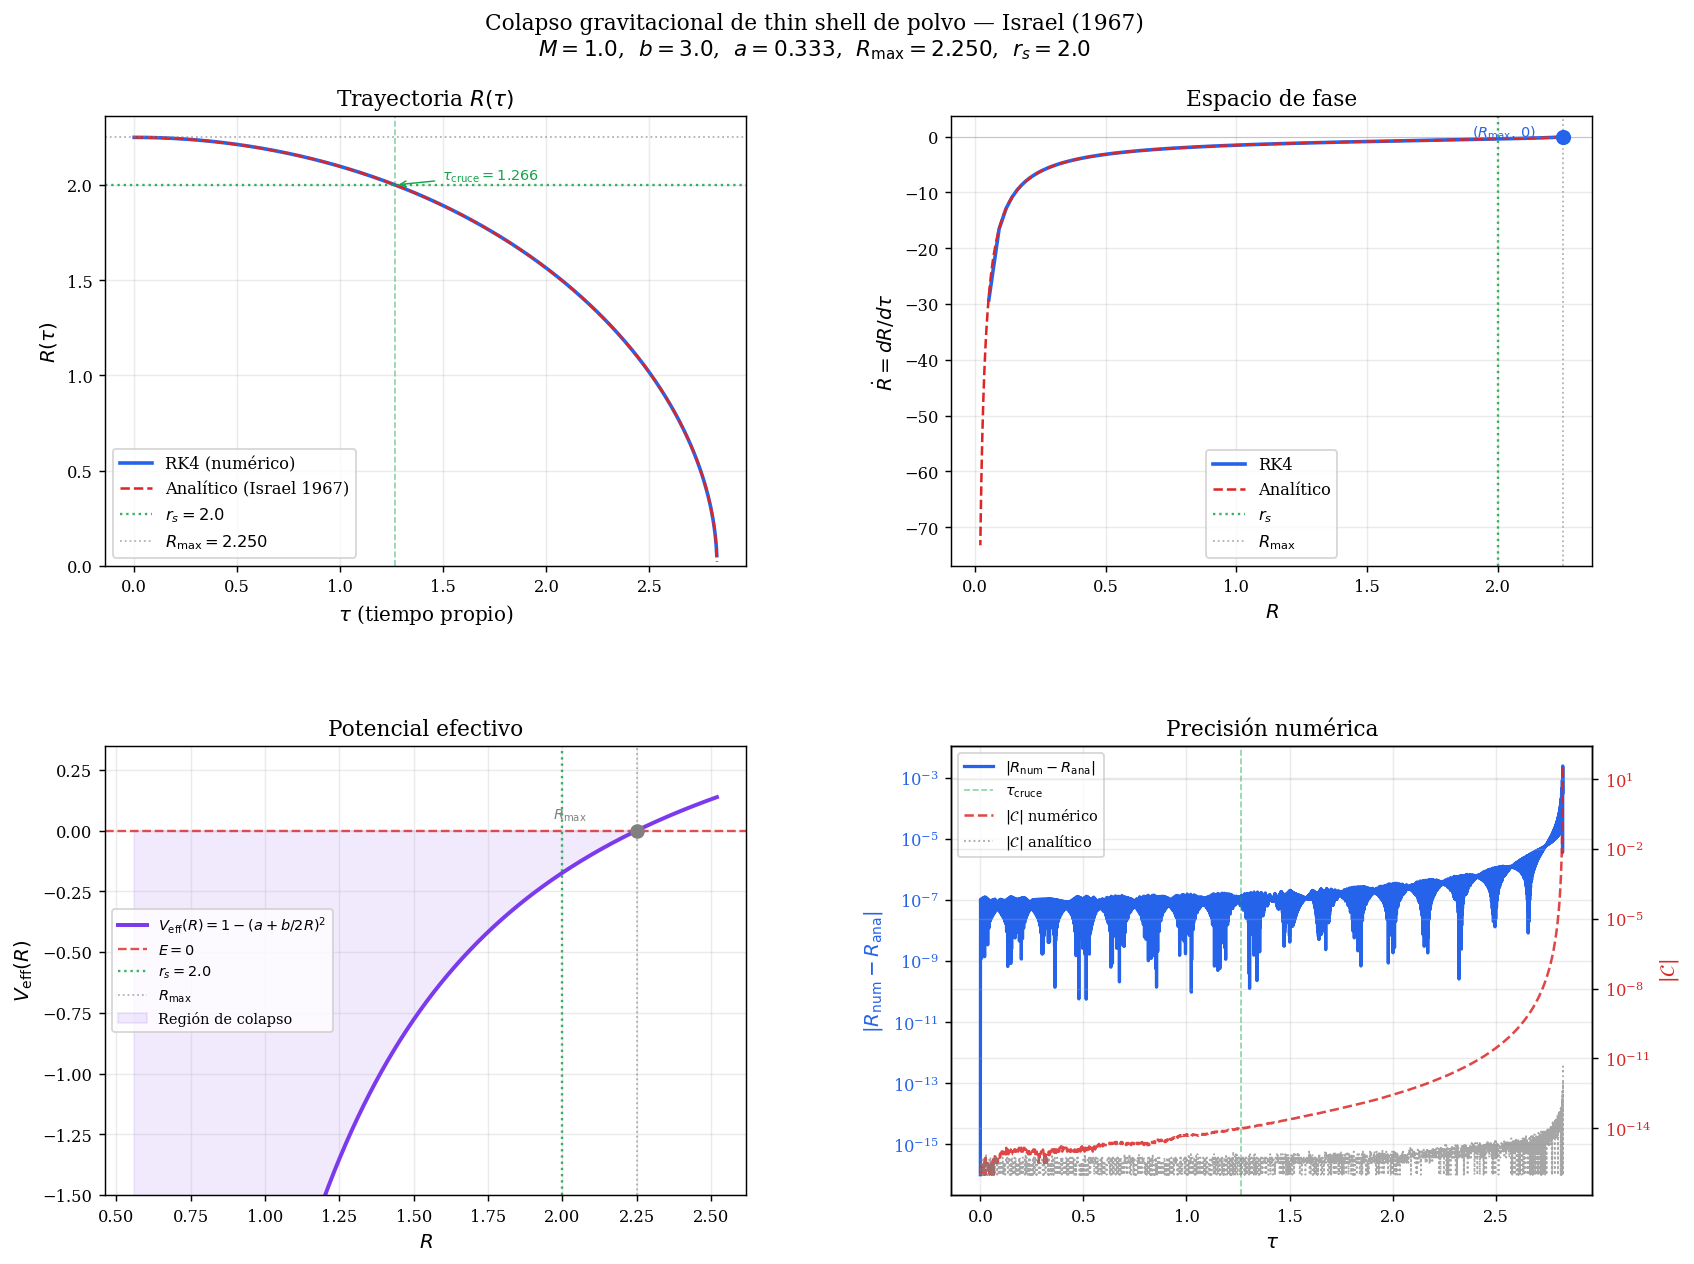

b=2.0: ShellParams inválidos:
  [1] R_max=2.0000 <= rs=2.0000. Shell empieza dentro del horizonte.
Guardado: parametric_scan.pdf


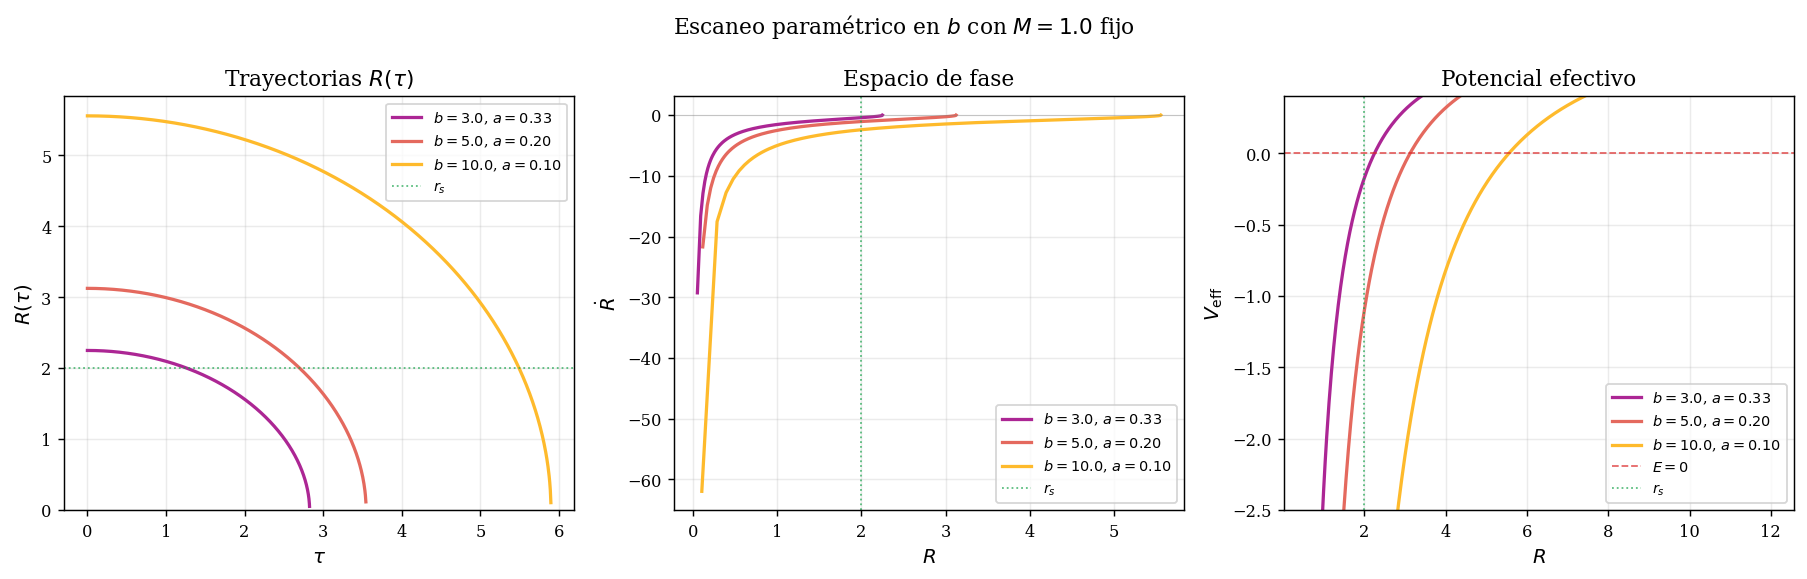

In [7]:
dashboard(M, b)
parametric_scan(M)

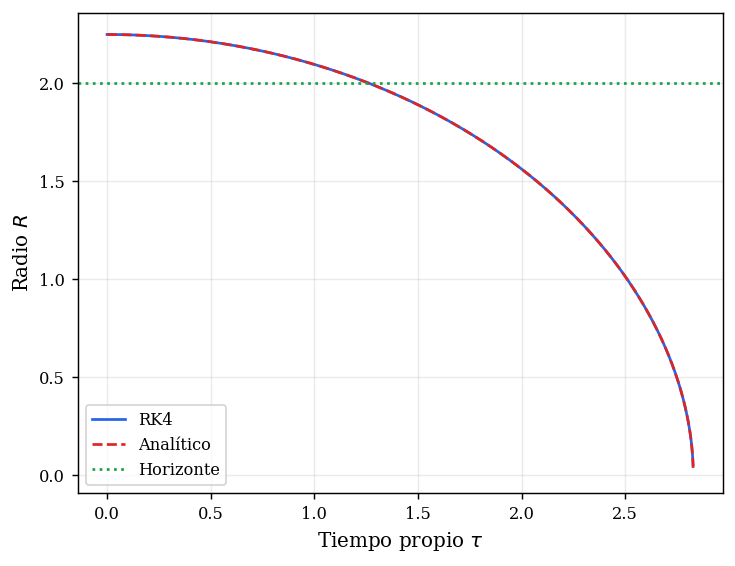

IntegratorResult(tau=array([0.00000000e+00, 1.87434124e-03, 3.74868248e-03, ...,
       2.82275791e+00, 2.82463225e+00, 2.82650659e+00], shape=(1509,)), R=array([2.25      , 2.24999948, 2.24999792, ..., 0.11927335, 0.09212318,
       0.05300202], shape=(1509,)), Rdot=array([-0.00000000e+00, -5.55360481e-04, -1.11072165e-03, ...,
       -1.28721744e+01, -1.65981765e+01, -2.92680587e+01], shape=(1509,)), C=array([ 0.00000000e+00,  2.22044605e-16, -2.22044605e-16, ...,
        3.80096700e-02,  4.11960033e-01,  3.77050681e+01], shape=(1509,)), epsilon=array([-0.66666667, -0.66666667, -0.66666667, ..., -0.66658652,
       -0.6661491 , -0.65150581], shape=(1509,)), horizon_crossing_tau=np.float64(1.2664083692315584), success=True, message='Detenido antes de la singularidad (R=-0.8276 < R_stop=0.0200).', rs=2.0, params={'method': 'RK4', 'h': np.float64(0.0018743412395355607), 'n_steps': 1509, 'max_step_fraction': 0.0005, 'M': 1.0, 'b': 3.0})


In [6]:
M = 1.0
b = 3.0    # a = M/b = 0.333 → positive_binding, R_max = 2.25
 
def run_simulation(M, b):
    params = ShellParams(M=M, b=b, integrator='rk4',
                         rtol=1e-10, atol=1e-12).validate()
    runner = ShellRunner(params)
    result = runner.run()
    bench  = runner.get_analytic_benchmark()
    report = runner.validate(result, bench)
    return params, result, bench, report

a,b,c,d = run_simulation(M, b)

plt.plot(b.tau, b.R, label='RK4', color=C_NUM)
plt.plot(c.tau, c.R, label='Analítico', color=C_ANA, linestyle='--')
plt.axhline(y=b.rs, color=C_HOR, linestyle=':', label='Horizonte')
plt.xlabel('Tiempo propio $ \\tau $')
plt.ylabel('Radio $R$')     
plt.legend()
plt.show()

print(b)

[0.00000000e+00 1.14020900e-03 2.28041780e-03 ... 2.82726231e+00
 2.82727331e+00 2.82728393e+00]


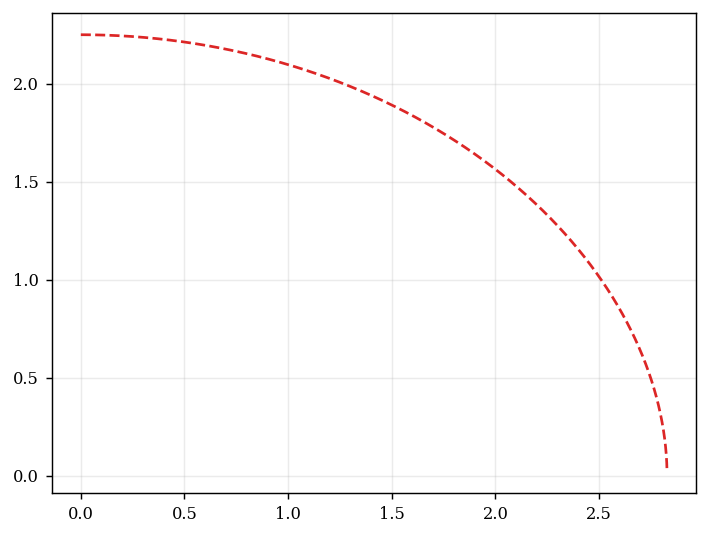

In [7]:
print(c.tau)

plt.plot(c.tau, c.R, label='Analítico', color=C_ANA, linestyle='--')


In [8]:
from matplotlib.widgets import Slider, Button
from matplotlib.colors import Normalize



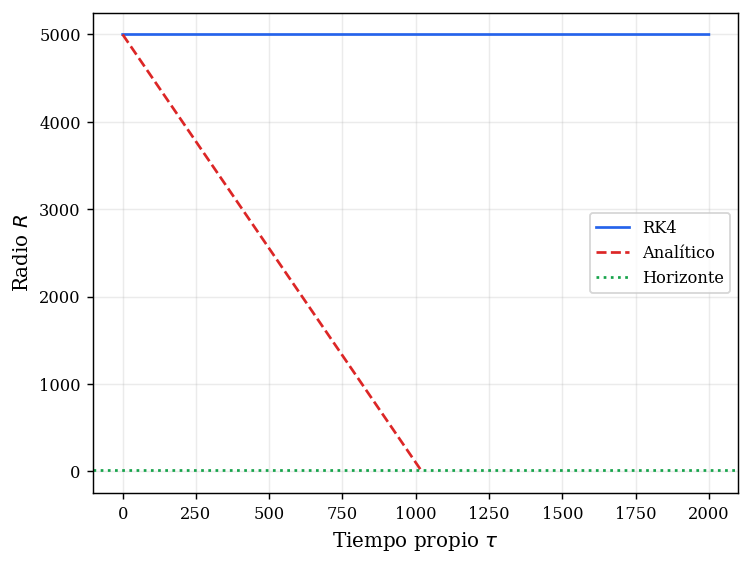

In [9]:
M = 5.0
b = 1.0    # a = M/b = 0.333 → positive_binding, R_max = 2.25
 
def run_simulation(M, b):
    params = ShellParams(M=M, b=b, integrator='rk4',
                         rtol=1e-10, atol=1e-12).validate()
    runner = ShellRunner(params)
    result = runner.run()
    bench  = runner.get_analytic_benchmark()
    report = runner.validate(result, bench)
    return params, result, bench, report

a,b,c,d = run_simulation(M, b)

plt.plot(b.tau, b.R, label='RK4', color=C_NUM)
plt.plot(c.tau, c.R, label='Analítico', color=C_ANA, linestyle='--')
plt.axhline(y=b.rs, color=C_HOR, linestyle=':', label='Horizonte')
plt.xlabel('Tiempo propio $ \\tau $')
plt.ylabel('Radio $R$')     
plt.legend()
plt.show()

